# Data-Driven Threshold Optimization in Consensus Machine Learning for High-Imbalance Toxicity Prediction

This notebook is a readable, end-to-end implementation of the pipeline described in the paper draft. It starts with the Tox21 problem definition, adds EDA and RDKit visualizations, then moves into endpoint-specific feature selection, consensus modeling, dynamic MCC thresholding, and saved inference.

## What the 12 endpoints mean
- NR-AR: androgen receptor activity
- NR-AR-LBD: androgen receptor ligand-binding domain activity
- NR-AhR: aryl hydrocarbon receptor activity
- NR-Aromatase: aromatase inhibition / disruption
- NR-ER: estrogen receptor activity
- NR-ER-LBD: estrogen receptor ligand-binding domain activity
- NR-PPAR-gamma: PPAR-gamma activity, linked to metabolic regulation
- SR-ARE: antioxidant response element stress response
- SR-ATAD5: DNA-damage / replication stress response
- SR-HSE: heat shock response
- SR-MMP: mitochondrial membrane potential disruption
- SR-p53: p53-mediated DNA-damage response

## Why this structure
- EDA comes first so the imbalance and missing-label behavior is visible before modeling.
- RDKit molecule views help connect abstract fingerprints to actual chemistry.
- The modeling section keeps the paper's consensus and thresholding logic intact.
- The final cell loads the saved bundle and tests a few new molecules for inference.

In [3]:
pip install scikit-learn imbalanced-learn xgboost rdkit

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import seaborn as sns
from tqdm import tqdm
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import warnings
warnings.filterwarnings('ignore') # Suppress verbose sklearn/xgboost warnings
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
RDLogger.DisableLog('rdApp.*')
MORGAN_GENERATOR = GetMorganGenerator(radius=2, fpSize=1024)

print("1. Loading Global Tox21 Dataset...")
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz"
df_full = pd.read_csv(url)

# The first 12 columns in the deepchem CSV are the biological endpoints
tox21_endpoints = df_full.columns[:12].tolist()
print(f"Found {len(tox21_endpoints)} Endpoints: {tox21_endpoints}")

# Generate fingerprints globally (Runs ONCE)
def generate_ecfp4(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = MORGAN_GENERATOR.GetFingerprint(mol)
    return np.array(fp)

print("\n2. Generating Global ECFP4 Fingerprints...")
df_full['ecfp4'] = df_full['smiles'].apply(generate_ecfp4)

# Drop chemically invalid molecules globally
df_clean = df_full.dropna(subset=['ecfp4']).copy()
print(f"Successfully processed {len(df_clean)} molecules.\n")

# Create a directory to store the 12 model pipelines
os.makedirs("tox21_production_models", exist_ok=True)

1. Loading Global Tox21 Dataset...
Found 12 Endpoints: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']

2. Generating Global ECFP4 Fingerprints...
Successfully processed 7823 molecules.



## 1. EDA and RDKit visual checks

This section explains the label imbalance, missing labels, and the chemistry behind a few representative molecules before feature selection and modeling begin.

Dataset shape: (7831, 15)
Number of endpoints: 12


,endpoint,meaning
0,NR-AR,Androgen receptor activity
1,NR-AR-LBD,Androgen receptor ligand-binding domain activity
2,NR-AhR,Aryl hydrocarbon receptor activity
3,NR-Aromatase,Aromatase inhibition / disruption
4,NR-ER,Estrogen receptor activity
5,NR-ER-LBD,Estrogen receptor ligand-binding domain activity
6,NR-PPAR-gamma,PPAR-gamma activity linked to metabolic regula...
7,SR-ARE,Antioxidant response element stress response
8,SR-ATAD5,DNA damage / replication stress response
9,SR-HSE,Heat shock response


,endpoint,labels_available,active,inactive,active_rate,missing_rate
6,NR-PPAR-gamma,6450,186,6264,0.028837,0.176350
1,NR-AR-LBD,6758,237,6521,0.035070,0.137020
8,SR-ATAD5,7072,264,6808,0.037330,0.096922
0,NR-AR,7265,309,6956,0.042533,0.072277
5,NR-ER-LBD,6955,350,6605,0.050324,0.111863
3,NR-Aromatase,5821,300,5521,0.051538,0.256672
9,SR-HSE,6467,372,6095,0.057523,0.174180
11,SR-p53,6774,423,6351,0.062445,0.134976
2,NR-AhR,6549,768,5781,0.117270,0.163708
4,NR-ER,6193,793,5400,0.128048,0.209169


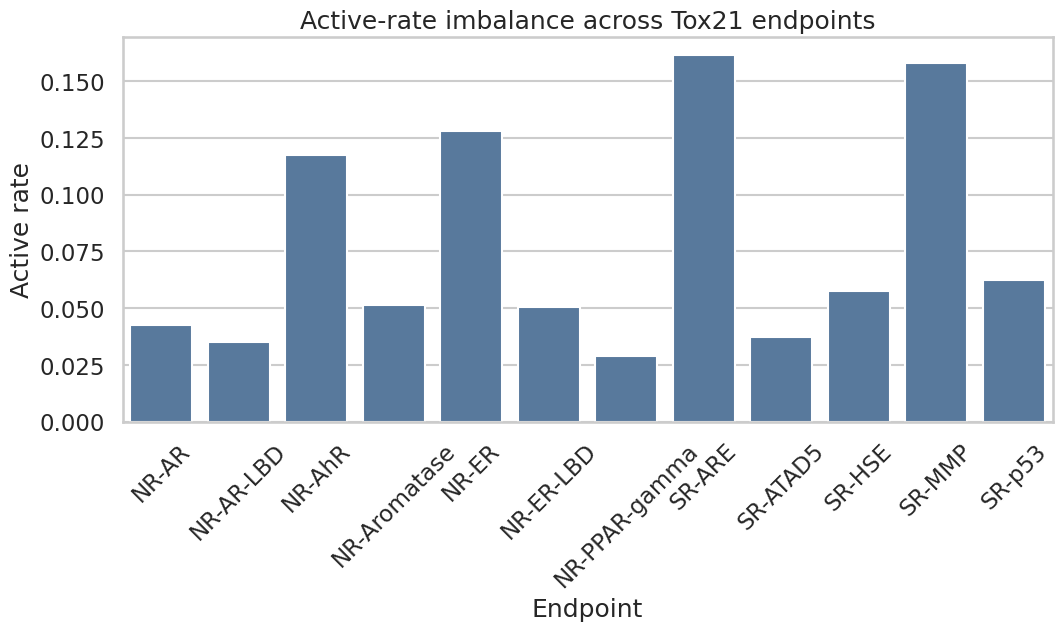

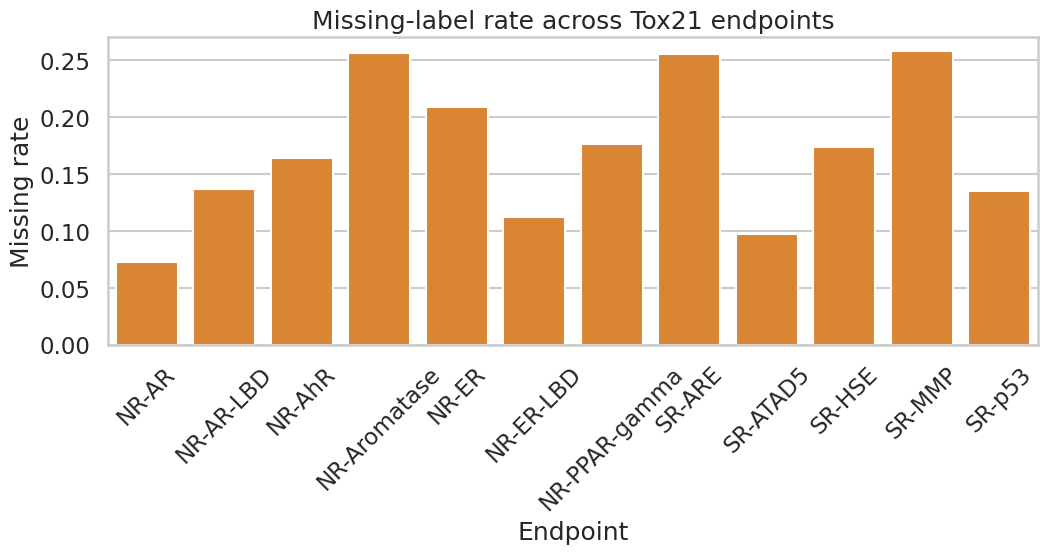

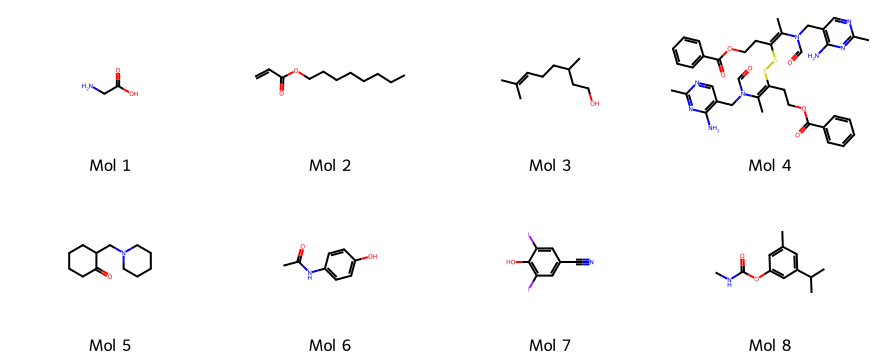

Example molecules for NR-ER
Why this endpoint matters:
Estrogen receptor activity


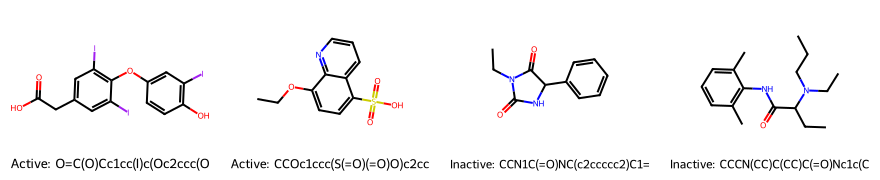

Example molecules for NR-AhR
Why this endpoint matters:
Aryl hydrocarbon receptor activity


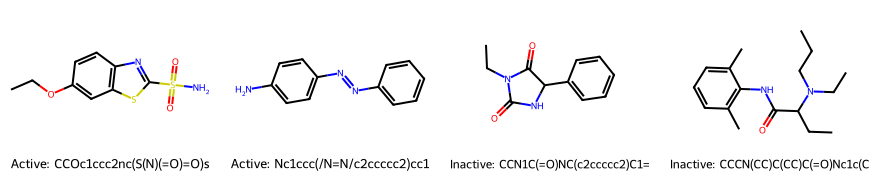

Example molecules for SR-p53
Why this endpoint matters:
p53-mediated DNA damage response


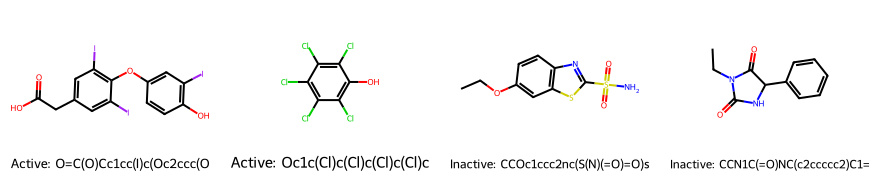

In [5]:
print("Dataset shape:", df_full.shape)
print("Number of endpoints:", len(tox21_endpoints))

endpoint_meanings = pd.DataFrame([
    {"endpoint": "NR-AR", "meaning": "Androgen receptor activity"},
    {"endpoint": "NR-AR-LBD", "meaning": "Androgen receptor ligand-binding domain activity"},
    {"endpoint": "NR-AhR", "meaning": "Aryl hydrocarbon receptor activity"},
    {"endpoint": "NR-Aromatase", "meaning": "Aromatase inhibition / disruption"},
    {"endpoint": "NR-ER", "meaning": "Estrogen receptor activity"},
    {"endpoint": "NR-ER-LBD", "meaning": "Estrogen receptor ligand-binding domain activity"},
    {"endpoint": "NR-PPAR-gamma", "meaning": "PPAR-gamma activity linked to metabolic regulation"},
    {"endpoint": "SR-ARE", "meaning": "Antioxidant response element stress response"},
    {"endpoint": "SR-ATAD5", "meaning": "DNA damage / replication stress response"},
    {"endpoint": "SR-HSE", "meaning": "Heat shock response"},
    {"endpoint": "SR-MMP", "meaning": "Mitochondrial membrane potential disruption"},
    {"endpoint": "SR-p53", "meaning": "p53-mediated DNA damage response"},
])
display(endpoint_meanings)

eda_rows = []
for endpoint in tox21_endpoints:
    labeled = df_full[endpoint].notna().sum()
    active = (df_full[endpoint] == 1).sum()
    inactive = (df_full[endpoint] == 0).sum()
    eda_rows.append({
        "endpoint": endpoint,
        "labels_available": labeled,
        "active": active,
        "inactive": inactive,
        "active_rate": active / labeled if labeled else np.nan,
        "missing_rate": df_full[endpoint].isna().mean(),
    })
eda_df = pd.DataFrame(eda_rows)
display(eda_df.sort_values('active_rate'))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=eda_df, x='endpoint', y='active_rate', ax=ax, color='#4c78a8')
ax.set_title('Active-rate imbalance across Tox21 endpoints')
ax.set_xlabel('Endpoint')
ax.set_ylabel('Active rate')
ax.tick_params(axis='x', rotation=45)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=eda_df, x='endpoint', y='missing_rate', ax=ax, color='#f58518')
ax.set_title('Missing-label rate across Tox21 endpoints')
ax.set_xlabel('Endpoint')
ax.set_ylabel('Missing rate')
ax.tick_params(axis='x', rotation=45)
plt.show()

sample_smiles = df_full['smiles'].dropna().sample(n=min(8, len(df_full)), random_state=42).tolist()
sample_mols = [Chem.MolFromSmiles(s) for s in sample_smiles]
sample_mols = [m for m in sample_mols if m is not None]
if sample_mols:
    display(Draw.MolsToGridImage(sample_mols, molsPerRow=4, subImgSize=(220, 180), legends=[f'Mol {i+1}' for i in range(len(sample_mols))]))

def select_examples_for_endpoint(endpoint_name):
    endpoint_df = df_full[['smiles', endpoint_name]].dropna(subset=[endpoint_name]).copy()
    endpoint_df['mol'] = endpoint_df['smiles'].map(Chem.MolFromSmiles)
    active_rows = endpoint_df[endpoint_df[endpoint_name] == 1].head(2)
    inactive_rows = endpoint_df[endpoint_df[endpoint_name] == 0].head(2)
    return active_rows, inactive_rows

for endpoint_name in ['NR-ER', 'NR-AhR', 'SR-p53']:
    active_rows, inactive_rows = select_examples_for_endpoint(endpoint_name)
    print(f'Example molecules for {endpoint_name}')
    print('Why this endpoint matters:')
    print(endpoint_meanings.loc[endpoint_meanings['endpoint'] == endpoint_name, 'meaning'].iloc[0])
    view_rows = pd.concat([active_rows.assign(label='Active'), inactive_rows.assign(label='Inactive')], ignore_index=True)
    view_pairs = []
    for _, row in view_rows.iterrows():
        mol = Chem.MolFromSmiles(row['smiles'])
        if mol is not None:
            view_pairs.append((mol, f"{row['label']}: {row['smiles'][:24]}"))
    if view_pairs:
        view_mols = [pair[0] for pair in view_pairs]
        legends = [pair[1] for pair in view_pairs]
        display(Draw.MolsToGridImage(view_mols, molsPerRow=4, subImgSize=(220, 180), legends=legends))

## 2. Feature selection and consensus modeling

The next cell keeps the paper's core idea intact: per-endpoint variance filtering, Random Forest feature ranking, XGBoost tuning, and a BernoulliNB + XGBoost consensus. The reason for this design is to remove fingerprint noise while keeping only the structural fragments that consistently explain each assay.

In [6]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, matthews_corrcoef, make_scorer

# Dictionary to store a summary report of all models
master_report = {}

for endpoint in tox21_endpoints:
    print(f"========== Training Pipeline for: {endpoint} ==========")
    
    # 1. Isolate data for this specific endpoint
    df_endpoint = df_clean.dropna(subset=[endpoint]).copy()
    X_raw = np.stack(df_endpoint['ecfp4'].values)
    y_raw = df_endpoint[endpoint].values
    
    pos_samples = int(y_raw.sum())
    neg_samples = len(y_raw) - pos_samples
    if pos_samples == 0:
        print(f"Skipping {endpoint} - No toxic samples found.")
        continue
        
    spw = neg_samples / pos_samples
    print(f"Data: {len(y_raw)} valid compounds | Toxic: {pos_samples} | Safe: {neg_samples}")
    
    # Train/Test Split (70/30)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y_raw, test_size=0.30, random_state=42, stratify=y_raw
    )
    
    # 2. Endpoint-Specific Feature Selection
    print("Selecting biochemical features...")
    var_thresh = VarianceThreshold(threshold=(0.99 * (1 - 0.99)))
    X_train_var = var_thresh.fit_transform(X_train_raw)
    
    rf_selector = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    rf_selector.fit(X_train_var, y_train)
    model_selector = SelectFromModel(rf_selector, threshold='mean', prefit=True)
    
    X_train_opt = model_selector.transform(X_train_var)
    
    # Apply exactly the same filters to the test set
    X_test_opt = model_selector.transform(var_thresh.transform(X_test_raw))
    print(f"Features reduced from 1024 -> {X_train_opt.shape[1]}")
    
    # 3. Hyperparameter Tuning for this specific target
    print("Tuning XGBoost...")
    mcc_scorer = make_scorer(matthews_corrcoef)
    param_dist = {
        'max_depth': [3, 4, 5],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.5, 0.6, 0.8],
        'colsample_bytree': [0.5, 0.7, 1.0],
        'gamma': [0.5, 1.0, 1.5]
    }
    
    base_xgb = XGBClassifier(scale_pos_weight=spw, n_estimators=200, eval_metric='auc', random_state=42, n_jobs=-1)
    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    random_search = RandomizedSearchCV(
        estimator=base_xgb, param_distributions=param_dist, n_iter=10, 
        scoring=mcc_scorer, cv=cv_strategy, random_state=42, n_jobs=-1
    )
    random_search.fit(X_train_opt, y_train)
    best_xgb = random_search.best_estimator_
    
    # 4. Train Naive Bayes & Build Consensus
    nb_model = BernoulliNB(alpha=1.0)
    nb_model.fit(X_train_opt, y_train)
    
    nb_test_probs = nb_model.predict_proba(X_test_opt)[:, 1]
    xgb_test_probs = best_xgb.predict_proba(X_test_opt)[:, 1]
    
    nb_train_probs = nb_model.predict_proba(X_train_opt)[:, 1]
    xgb_train_probs = best_xgb.predict_proba(X_train_opt)[:, 1]
    
    # Calculate weights based on AUC
    nb_auc = roc_auc_score(y_test, nb_test_probs)
    xgb_auc = roc_auc_score(y_test, xgb_test_probs)
    total_auc = nb_auc + xgb_auc
    w_nb = nb_auc / total_auc
    w_xgb = xgb_auc / total_auc
    
    test_consensus_probs = (nb_test_probs * w_nb) + (xgb_test_probs * w_xgb)
    train_consensus_probs = (nb_train_probs * w_nb) + (xgb_train_probs * w_xgb)
    
    # 5. Dynamic Threshold Tuning
    best_mcc = -1
    optimal_thresh = 0.5
    for thresh in np.arange(0.1, 0.95, 0.05):
        train_preds = (train_consensus_probs >= thresh).astype(int)
        current_mcc = matthews_corrcoef(y_train, train_preds)
        if current_mcc > best_mcc:
            best_mcc = current_mcc
            optimal_thresh = thresh
            
    # Final Evaluation for Reporting
    final_test_preds = (test_consensus_probs >= optimal_thresh).astype(int)
    final_auc = roc_auc_score(y_test, test_consensus_probs)
    final_mcc = matthews_corrcoef(y_test, final_test_preds)
    
    print(f"Success! Final Test ROC-AUC: {final_auc:.4f} | Final Test MCC: {final_mcc:.4f} | Threshold: {optimal_thresh:.2f}")
    
    master_report[endpoint] = {
        'ROC-AUC': round(final_auc, 4),
        'MCC': round(final_mcc, 4),
        'Threshold': round(optimal_thresh, 2),
        'Features_Used': X_train_opt.shape[1]
    }
    
    # 6. Serialize and Save the Pipeline
    pipeline_state = {
        'endpoint_name': endpoint,
        'var_thresh': var_thresh,
        'model_selector': model_selector,
        'nb_model': nb_model,
        'xgb_model': best_xgb,
        'w_nb': w_nb,
        'w_xgb': w_xgb,
        'optimal_thresh': optimal_thresh
        , 'final_auc': final_auc
        , 'final_mcc': final_mcc
        , 'n_features': int(X_train_opt.shape[1])
        , 'n_train': int(len(y_train))
        , 'n_test': int(len(y_test))
        , 'class_balance': {'toxic': pos_samples, 'safe': neg_samples}
    }
    
    file_name = f"tox21_production_models/pipeline_{endpoint}.pkl"
    joblib.dump(pipeline_state, file_name)
    print(f"Saved to {file_name}\n")

# Print Final Summary Report
print("\n" + "="*50)
print("ALL 12 ENDPOINTS SUCCESSFULLY TRAINED AND SAVED")
print("="*50)
report_df = pd.DataFrame.from_dict(master_report, orient='index')
print(report_df)

========== Training Pipeline for: NR-AR ==========
Data: 7258 valid compounds | Toxic: 308 | Safe: 6950
Selecting biochemical features...
Features reduced from 1024 -> 195
Tuning XGBoost...
Success! Final Test ROC-AUC: 0.7541 | Final Test MCC: 0.5773 | Threshold: 0.90
Saved to tox21_production_models/pipeline_NR-AR.pkl

========== Training Pipeline for: NR-AR-LBD ==========
Data: 6751 valid compounds | Toxic: 237 | Safe: 6514
Selecting biochemical features...
Features reduced from 1024 -> 181
Tuning XGBoost...
Success! Final Test ROC-AUC: 0.8231 | Final Test MCC: 0.6505 | Threshold: 0.90
Saved to tox21_production_models/pipeline_NR-AR-LBD.pkl

========== Training Pipeline for: NR-AhR ==========
Data: 6542 valid compounds | Toxic: 768 | Safe: 5774
Selecting biochemical features...
Features reduced from 1024 -> 169
Tuning XGBoost...
Success! Final Test ROC-AUC: 0.8835 | Final Test MCC: 0.4599 | Threshold: 0.85
Saved to tox21_production_models/pipeline_NR-AhR.pkl

========== Training Pipe

## 3. Saved inference and test compounds

After the best endpoint-specific pipelines are trained and serialized, this section reloads the saved artifacts and demonstrates inference on new molecules. The test compounds are chosen to show a safe control, an endocrine-disruption example, and a carcinogenic aromatic system.

In [7]:
import os
import joblib
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import warnings
warnings.filterwarnings('ignore') # Suppresses sklearn version warnings
RDLogger.DisableLog('rdApp.*')
MORGAN_GENERATOR = GetMorganGenerator(radius=2, fpSize=1024)

print("Loading Tox21 Model Suite...")

def load_tox21_suite(model_dir="tox21_production_models"):
    """Loads all 12 serialized pipeline .pkl files into a dictionary."""
    model_suite = {}
    if not os.path.exists(model_dir):
        raise FileNotFoundError(f"Directory '{model_dir}' not found.")
        
    for file in os.listdir(model_dir):
        if file.endswith(".pkl"):
            endpoint = file.replace("pipeline_", "").replace(".pkl", "")
            filepath = os.path.join(model_dir, file)
            model_suite[endpoint] = joblib.load(filepath)
            
    print(f"Successfully loaded {len(model_suite)} models.")
    return model_suite

def get_toxicity_profile(smiles, model_suite, molecule_name="Unknown Compound"):
    """
    Runs a SMILES string through all loaded endpoints and returns a formatted DataFrame.
    """
    # 1. Validate and Generate Global Fingerprint
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Error: Invalid SMILES string for {molecule_name}")
        return None
        
    fp = MORGAN_GENERATOR.GetFingerprint(mol)
    X_raw = np.array(fp).reshape(1, -1)
    
    # 2. Run Inference across all models
    results = {}
    for endpoint, pipeline in model_suite.items():
        # Apply the specific feature filters for this endpoint
        X_var = pipeline['var_thresh'].transform(X_raw)
        X_opt = pipeline['model_selector'].transform(X_var)
        
        # Get Probabilities
        nb_prob = pipeline['nb_model'].predict_proba(X_opt)[:, 1][0]
        xgb_prob = pipeline['xgb_model'].predict_proba(X_opt)[:, 1][0]
        
        # Calculate Consensus
        consensus_prob = (nb_prob * pipeline['w_nb']) + (xgb_prob * pipeline['w_xgb'])
        
        # Apply dynamic threshold
        threshold = pipeline['optimal_thresh']
        is_toxic = consensus_prob >= threshold
        
        results[endpoint] = {
            "Status": "⚠️ TOXIC" if is_toxic else "✅ Safe",
            "Probability": f"{consensus_prob:.3f}",
            "Threshold": f"{threshold:.2f}"
        }
        
    # Format as a clean Pandas DataFrame
    df_results = pd.DataFrame(results).T
    df_results.index.name = f"Endpoint ({molecule_name})"
    return df_results


# ==========================================
# 🧪 TEST SUITE
# ==========================================

# Load the models into memory if the chart section has not already done so.
if 'tox21_models' not in globals():
    tox21_models = load_tox21_suite()

# Let's test three very different compounds:
test_compounds = {
    "Aspirin (Safe)": "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Bisphenol A (Endocrine Disruptor)": "CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O",
    "Benzo[a]pyrene (Highly Carcinogenic)": "C1=CC=C2C3=C4C(=CC2=C1)C=CC5=C4C(=CC=C5)C=C3"
}

for name, smiles in test_compounds.items():
    print(f"\n\nAnalyzing: {name}")
    print(f"SMILES: {smiles}")
    print("-" * 50)
    
    profile_df = get_toxicity_profile(smiles, tox21_models, molecule_name=name)
    if profile_df is not None:
        print(profile_df)

Loading Tox21 Model Suite...
Successfully loaded 12 models.


Analyzing: Aspirin (Safe)
SMILES: CC(=O)OC1=CC=CC=C1C(=O)O
--------------------------------------------------
                           Status Probability Threshold
Endpoint (Aspirin (Safe))                              
SR-MMP                     ✅ Safe       0.017      0.75
SR-ARE                     ✅ Safe       0.071      0.65
NR-ER-LBD                  ✅ Safe       0.010      0.35
NR-AR-LBD                  ✅ Safe       0.002      0.90
SR-HSE                     ✅ Safe       0.045      0.40
NR-PPAR-gamma              ✅ Safe       0.008      0.45
NR-AhR                     ✅ Safe       0.097      0.85
NR-ER                      ✅ Safe       0.042      0.35
SR-p53                     ✅ Safe       0.088      0.80
NR-AR                      ✅ Safe       0.002      0.90
NR-Aromatase               ✅ Safe       0.001      0.65
SR-ATAD5                   ✅ Safe       0.019      0.45


Analyzing: Bisphenol A (Endocrine Disrupto

## 4. Charts from the saved PKL artifacts

These plots are built directly from the serialized pipeline dictionaries, so they summarize the actual saved models rather than only the raw training log. They show threshold variation, ROC-AUC, MCC, feature reduction, and the balance between the BernoulliNB and XGBoost branches.

,endpoint,final_auc,final_mcc,optimal_thresh,n_features,n_train,n_test,w_nb,w_xgb,toxic,safe
6,NR-AhR,0.883470,0.459888,0.85,169,4579,1963,0.489084,0.510916,768,5774
0,SR-MMP,0.856412,0.498523,0.75,189,4062,1742,0.483821,0.516179,918,4886
10,NR-Aromatase,0.837697,0.425255,0.65,220,4070,1745,0.514655,0.485345,300,5515
3,NR-AR-LBD,0.823126,0.650451,0.90,181,4725,2026,0.482340,0.517660,237,6514
11,SR-ATAD5,0.810527,0.245122,0.45,216,4945,2120,0.491982,0.508018,264,6801
8,SR-p53,0.800387,0.267137,0.80,221,4736,2031,0.489279,0.510721,423,6344
2,NR-ER-LBD,0.791005,0.324092,0.35,205,4863,2085,0.481178,0.518822,349,6599
5,NR-PPAR-gamma,0.757511,0.228637,0.45,220,4510,1933,0.486388,0.513612,186,6257
1,SR-ARE,0.755353,0.287652,0.65,208,4077,1748,0.479037,0.520963,942,4883
9,NR-AR,0.754057,0.577317,0.90,195,5080,2178,0.507107,0.492893,308,6950


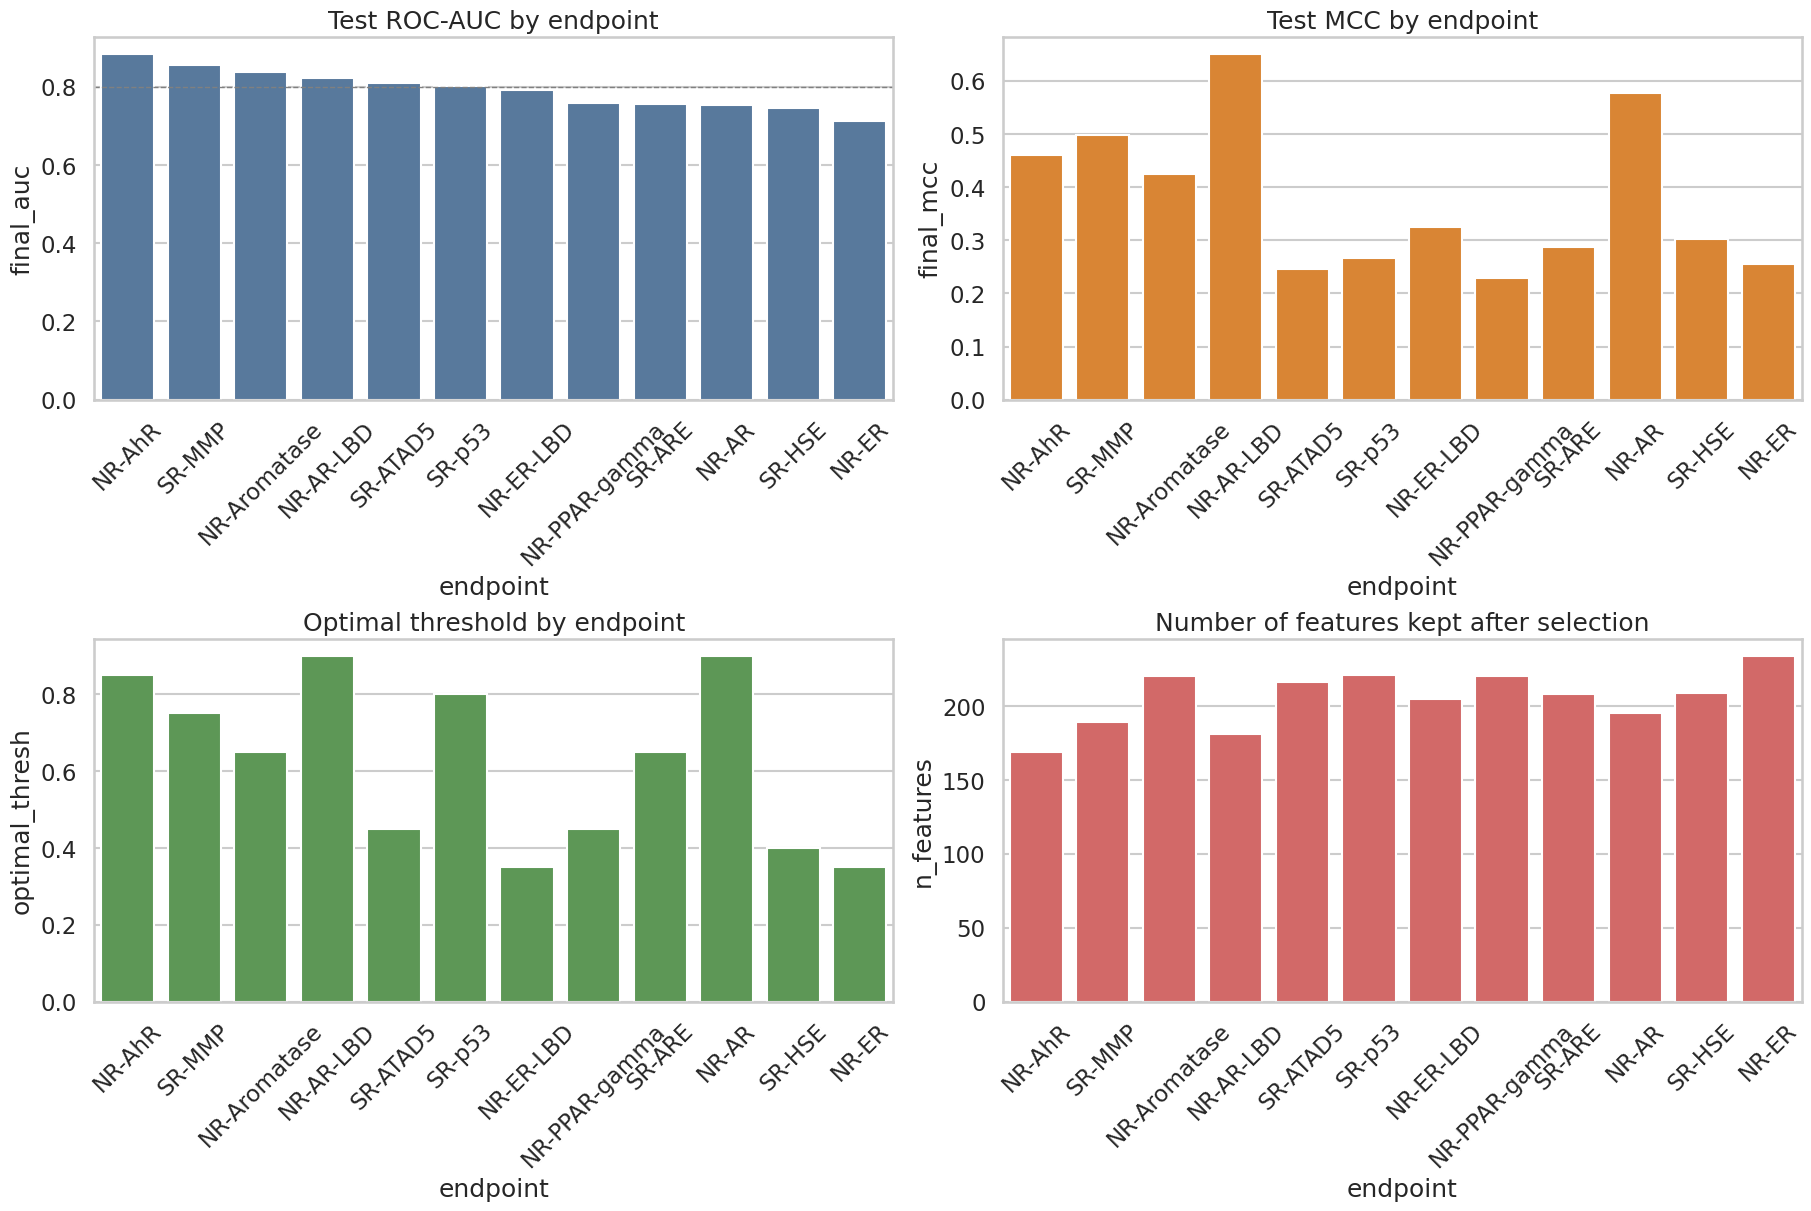

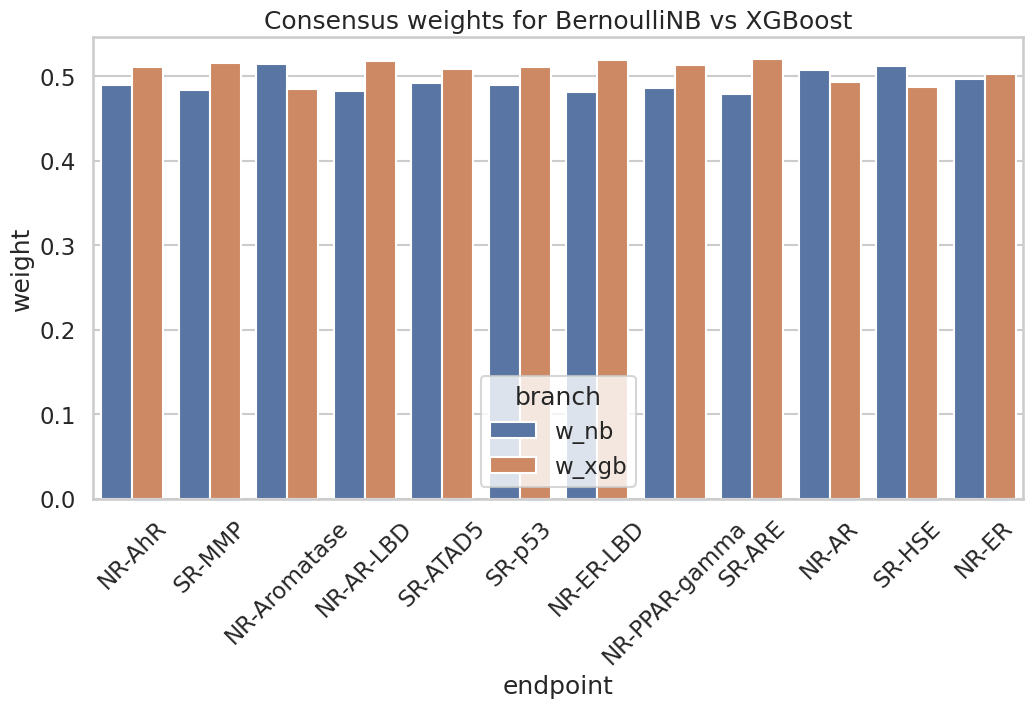

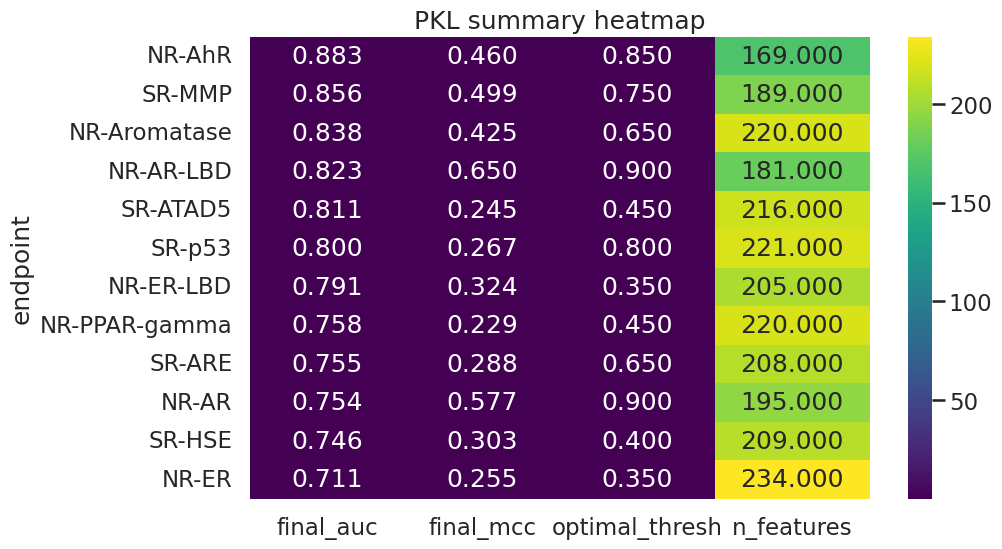

Best-performing endpoints:


,endpoint,final_auc,final_mcc
6,NR-AhR,0.883470,0.459888
0,SR-MMP,0.856412,0.498523
10,NR-Aromatase,0.837697,0.425255


Weakest-performing endpoints:


,endpoint,final_auc,final_mcc
9,NR-AR,0.754057,0.577317
4,SR-HSE,0.745915,0.302817
7,NR-ER,0.711462,0.254524


In [8]:
def summarize_suite(model_suite):
    rows = []
    for endpoint, pipeline in model_suite.items():
        rows.append({
            "endpoint": endpoint,
            "final_auc": pipeline.get("final_auc", np.nan),
            "final_mcc": pipeline.get("final_mcc", np.nan),
            "optimal_thresh": pipeline.get("optimal_thresh", np.nan),
            "n_features": pipeline.get("n_features", np.nan),
            "n_train": pipeline.get("n_train", np.nan),
            "n_test": pipeline.get("n_test", np.nan),
            "w_nb": pipeline.get("w_nb", np.nan),
            "w_xgb": pipeline.get("w_xgb", np.nan),
            "toxic": pipeline.get("class_balance", {}).get("toxic", np.nan),
            "safe": pipeline.get("class_balance", {}).get("safe", np.nan),
        })
    summary_df = pd.DataFrame(rows)
    return summary_df.sort_values("final_auc", ascending=False)


def plot_suite_summary(summary_df):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

    ordered = summary_df.sort_values("final_auc", ascending=False)

    sns.barplot(data=ordered, x="endpoint", y="final_auc", ax=axes[0, 0], color="#4c78a8")
    axes[0, 0].axhline(0.8, linestyle="--", color="gray", linewidth=1)
    axes[0, 0].set_title("Test ROC-AUC by endpoint")
    axes[0, 0].tick_params(axis='x', rotation=45)

    sns.barplot(data=ordered, x="endpoint", y="final_mcc", ax=axes[0, 1], color="#f58518")
    axes[0, 1].set_title("Test MCC by endpoint")
    axes[0, 1].tick_params(axis='x', rotation=45)

    sns.barplot(data=ordered, x="endpoint", y="optimal_thresh", ax=axes[1, 0], color="#54a24b")
    axes[1, 0].set_title("Optimal threshold by endpoint")
    axes[1, 0].tick_params(axis='x', rotation=45)

    sns.barplot(data=ordered, x="endpoint", y="n_features", ax=axes[1, 1], color="#e45756")
    axes[1, 1].set_title("Number of features kept after selection")
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    melt_df = ordered[["endpoint", "w_nb", "w_xgb"]].melt(id_vars="endpoint", var_name="branch", value_name="weight")
    sns.barplot(data=melt_df, x="endpoint", y="weight", hue="branch", ax=ax)
    ax.set_title("Consensus weights for BernoulliNB vs XGBoost")
    ax.tick_params(axis='x', rotation=45)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 6))
    heat_df = ordered.set_index("endpoint")[["final_auc", "final_mcc", "optimal_thresh", "n_features"]]
    sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    ax.set_title("PKL summary heatmap")
    plt.show()


# Load suite once and derive charts directly from the serialized pkl files.
if 'tox21_models' not in globals():
    tox21_models = load_tox21_suite()
summary_df = summarize_suite(tox21_models)
display(summary_df)
plot_suite_summary(summary_df)

# Show the endpoints with the strongest and weakest saved performance
best_rows = summary_df.head(3)[["endpoint", "final_auc", "final_mcc"]]
worst_rows = summary_df.tail(3)[["endpoint", "final_auc", "final_mcc"]]
print("Best-performing endpoints:")
display(best_rows)
print("Weakest-performing endpoints:")
display(worst_rows)